# New York City Taxi Fare Prediction

We'll train a machine learning model to predict the fare for a taxi ride in New York city given information like pickup date & time, pickup location, drop location and no. of passengers. 

Dataset Link: https://www.kaggle.com/c/new-york-city-taxi-fare-prediction

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import numpy as np

## 1. Download the Dataset

- Install required libraries
- Download data from Kaggle
- View dataset files
- Load training set with Pandas
- Load test set with Pandas

### Loading Training and Testing Set

Loading the entire dataset into Pandas is going to be slow, so we can use the following optimizations:

- Ignore the `key` column
- Parse pickup datetime while loading data 
- Specify data types for other columns
   - `float32` for geo coordinates
   - `float32` for fare amount
   - `uint8` for passenger count
- Work with a 1% sample of the data (~500k rows)

We can apply these optimizations while using [`pd.read_csv`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html)

In [3]:
import random
# Change this
sample_frac = 0.1

In [4]:
%%time
selected_cols = 'fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count'.split(',')
dtypes = {
    'fare_amount': 'float32',
    'pickup_longitude': 'float32',
    'pickup_latitude': 'float32',
    'dropoff_longitude': 'float32',
    'passenger_count': 'float32'
}

def skip_row(row_idx):
    if row_idx == 0:
        return False
    return random.random() > sample_frac

random.seed(42)
df = pd.read_csv("./train.csv", 
                 usecols=selected_cols,
                 dtype=dtypes, 
                 parse_dates=['pickup_datetime'], 
                 skiprows=skip_row)

CPU times: total: 1min 31s
Wall time: 1min 32s


In [5]:
df.shape
# Using just 10% of the dataset to reduce train time

(5542602, 7)

In [6]:
test_df = pd.read_csv('./test.csv', parse_dates=['pickup_datetime'])

In [7]:
test_df.head(5)

,key,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,2015-01-27 13:08:24.0000002,2015-01-27 13:08:24+00:00,-73.973320,40.763805,-73.981430,40.743835,1
1,2015-01-27 13:08:24.0000003,2015-01-27 13:08:24+00:00,-73.986862,40.719383,-73.998886,40.739201,1
2,2011-10-08 11:53:44.0000002,2011-10-08 11:53:44+00:00,-73.982524,40.751260,-73.979654,40.746139,1
3,2012-12-01 21:12:12.0000002,2012-12-01 21:12:12+00:00,-73.981160,40.767807,-73.990448,40.751635,1
4,2012-12-01 21:12:12.0000003,2012-12-01 21:12:12+00:00,-73.966046,40.789775,-73.988565,40.744427,1


In [8]:
test_df.shape

(9914, 7)

Observations:

- This is a supervised learning regression problem
- Training data is 5.5 GB in size
- Training data has 5.5 million rows
- Test set is much smaller (< 10,000 rows)
- The training set has 8 columns:
    - `key` (a unique identifier)
    - `fare_amount` (target column)
    - `pickup_datetime`
    - `pickup_longitude`
    - `pickup_latitude`
    - `dropoff_longitude`
    - `dropoff_latitude`
    - `passenger_count`
- The test set has all columns except the target column `fare_amount`.
- The submission file should contain the `key` and `fare_amount` for each test sample.


## 2. Explore the Dataset

- Basic info about training set
- Basic info about test set
- Exploratory data analysis & visualization
- Ask & answer questions

In [9]:
df.info

<bound method DataFrame.info of          fare_amount           pickup_datetime  pickup_longitude  \
0               16.9 2010-01-05 16:52:16+00:00        -74.016045   
1               16.5 2012-01-04 17:22:00+00:00        -73.951302   
2                8.9 2009-09-02 01:11:00+00:00        -73.980659   
3                4.1 2009-11-06 01:04:03+00:00        -73.991600   
4                4.0 2014-12-06 20:36:22+00:00        -73.979813   
...              ...                       ...               ...   
5542597          6.0 2014-10-18 07:51:00+00:00        -73.997681   
5542598          5.7 2010-11-18 07:08:58+00:00        -73.997589   
5542599          8.0 2013-12-21 14:03:00+00:00        -73.976486   
5542600         13.0 2013-09-04 20:20:00+00:00        -73.995605   
5542601         10.5 2010-08-10 11:19:42+00:00        -73.974640   

         pickup_latitude  dropoff_longitude  dropoff_latitude  passenger_count  
0              40.711304         -73.979271         40.782004         

In [10]:
df.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,5.542602e+06,5.542602e+06,5.542602e+06,5.542569e+06,5.542569e+06,5.542602e+06
mean,1.136259e+01,-7.250569e+01,3.991776e+01,-7.250184e+01,3.991750e+01,1.686349e+00
std,4.109730e+01,1.284903e+01,1.017996e+01,1.300960e+01,9.816180e+00,1.324577e+00
min,-3.000000e+02,-3.439245e+03,-3.492264e+03,-3.379079e+03,-3.547887e+03,0.000000e+00
25%,6.000000e+00,-7.399207e+01,4.073493e+01,-7.399140e+01,4.073402e+01,1.000000e+00
50%,8.500000e+00,-7.398180e+01,4.075265e+01,-7.398016e+01,4.075314e+01,1.000000e+00
75%,1.250000e+01,-7.396708e+01,4.076712e+01,-7.396368e+01,4.076809e+01,2.000000e+00
max,9.396336e+04,3.457626e+03,3.376602e+03,3.442185e+03,3.400392e+03,2.080000e+02


In [11]:
df.pickup_datetime.min(), df.pickup_datetime.max()

(Timestamp('2009-01-01 00:01:56+0000', tz='UTC'),
 Timestamp('2015-06-30 23:59:54+0000', tz='UTC'))

Observations about training data:

- 550k+ rows, as expected
- No missing data (in the sample)
- `fare_amount` ranges from \$-52.0 to \$499.0 
- `passenger_count` ranges from 0 to 208 
- There seem to be some errors in the latitude & longitude values
- Dates range from 1st Jan 2009 to 30th June 2015
- The dataset takes up ~19 MB of space in the RAM

We may need to deal with outliers and data entry errors before we train our model.

### Test Set

In [12]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9914 entries, 0 to 9913
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype              
---  ------             --------------  -----              
 0   key                9914 non-null   object             
 1   pickup_datetime    9914 non-null   datetime64[ns, UTC]
 2   pickup_longitude   9914 non-null   float64            
 3   pickup_latitude    9914 non-null   float64            
 4   dropoff_longitude  9914 non-null   float64            
 5   dropoff_latitude   9914 non-null   float64            
 6   passenger_count    9914 non-null   int64              
dtypes: datetime64[ns, UTC](1), float64(4), int64(1), object(1)
memory usage: 542.3+ KB


In [13]:
test_df.describe()

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000
mean,-73.974722,40.751041,-73.973657,40.751743,1.671273
std,0.042774,0.033541,0.039072,0.035435,1.278747
min,-74.252193,40.573143,-74.263242,40.568973,1.000000
25%,-73.992501,40.736125,-73.991247,40.735254,1.000000
50%,-73.982326,40.753051,-73.980015,40.754065,1.000000
75%,-73.968013,40.767113,-73.964059,40.768757,2.000000
max,-72.986532,41.709555,-72.990963,41.696683,6.000000


In [14]:
test_df.pickup_datetime.min(), test_df.pickup_datetime.max()

(Timestamp('2009-01-01 11:04:24+0000', tz='UTC'),
 Timestamp('2015-06-30 20:03:50+0000', tz='UTC'))

Some observations about the test set:

- 9914 rows of data
- No missing values
- No obvious data entry errors
- 1 to 6 passengers (we can limit training data to this range)
- Latitudes lie between 40 and 42
- Longitudes lie between -75 and -72
- Pickup dates range from Jan 1st 2009 to Jun  30th 2015 (same as training set)

We can use the ranges of the test set to drop outliers/invalid data from the training set.

### Exploratory Data Analysis and Visualization

**Exercise**: Create graphs (histograms, line charts, bar charts, scatter plots, box plots, geo maps etc.) to study the distrubtion of values in each column, and the relationship of each input column to the target.


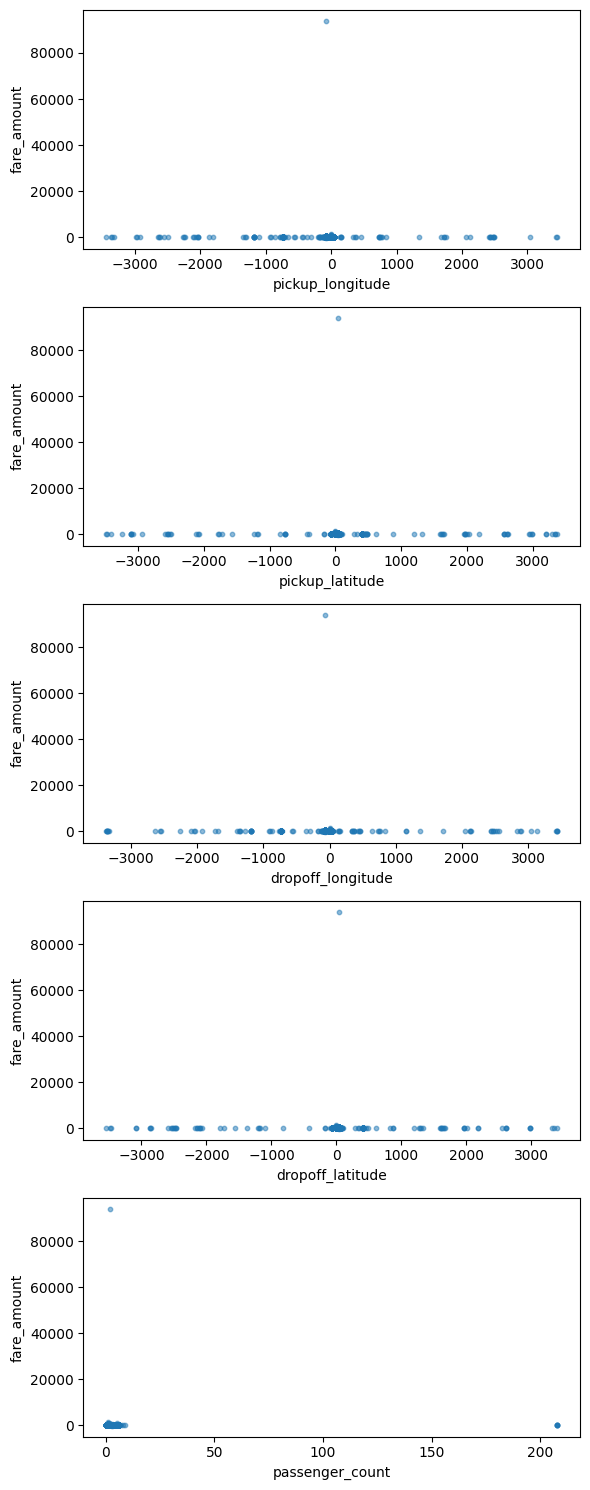

In [15]:
# Select numeric columns except 'fare_amount'
cols = df.select_dtypes(include=['float32', 'float64']).columns.tolist()
cols.remove('fare_amount')

# Create 6x1 subplots
fig, axes = plt.subplots(len(cols), 1, figsize=(6, len(cols)*3))

for i, col in enumerate(cols):
    axes[i].scatter(df[col], df['fare_amount'], alpha=0.5, s=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('fare_amount')

plt.tight_layout()
plt.show()

In [16]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=['float32', 'float64'])

# Correlation of fare_amount with all numeric columns
fare_corr = numeric_df.corr()['fare_amount'].sort_values(ascending=False)

print(fare_corr)

fare_amount          1.000000
passenger_count      0.003163
dropoff_longitude    0.002155
pickup_longitude     0.001997
pickup_latitude     -0.001490
dropoff_latitude    -0.001638
Name: fare_amount, dtype: float64


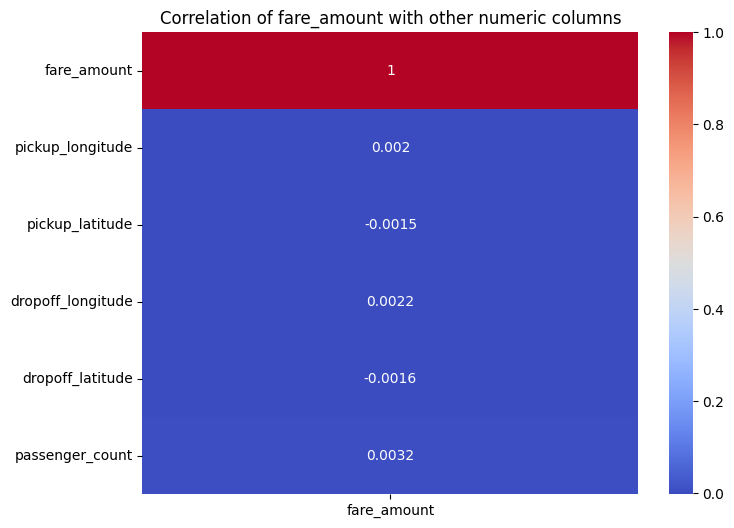

In [17]:
plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr()[['fare_amount']], annot=True, cmap='coolwarm')
plt.title('Correlation of fare_amount with other numeric columns')
plt.show()

No strong correlation found in the given data, we may have to extract features using dates and feature engineering.

### Ask & Answer Questions

**Exercise**: Ask & answer questions about the dataset: 

1. What is the busiest day of the week?
2. What is the busiest time of the day?
3. In which month are fares the highest?
4. Which pickup locations have the highest fares?
5. Which drop locations have the highest fares?
6. What is the average ride distance?

EDA + asking questions will help you develop a deeper understand of the data and give you ideas for feature engineering.

## 3. Prepare Dataset for Training

- Split Training & Validation Set
- Fill/Remove Missing Values
- Extract Inputs & Outputs
   - Training
   - Validation
   - Test

### Split Training & Validation Set

We'll set aside 20% of the training data as the validation set, to evaluate the models we train on previously unseen data. 

Since the test set and training set have the same date ranges, we can pick a random 20% fraction.

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

In [20]:
len(train_df), len(val_df)

(4434081, 1108521)

### Extract Inputs and Outputs

In [21]:
df.columns

Index(['fare_amount', 'pickup_datetime', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'passenger_count'],
      dtype='object')

In [22]:
input_cols = ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count']

In [23]:
target_col = 'fare_amount'

#### Training

In [24]:
train_inputs = train_df[input_cols]
train_targets = train_df[target_col]

In [25]:
train_inputs

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
2056898,-73.783417,40.648640,-73.738358,40.770730,6.0
2987026,-73.960716,40.780994,-73.969803,40.765275,1.0
838145,-73.973808,40.752071,-73.949394,40.777280,1.0
4760740,-73.975105,40.753578,-73.976768,40.735029,1.0
2580632,-73.921036,40.756550,-73.943451,40.747370,2.0
...,...,...,...,...,...
1570006,-73.980797,40.774883,-73.981026,40.744616,1.0
2234489,-73.961388,40.780155,-73.956810,40.767911,2.0
4926484,-73.949440,40.781200,-73.982399,40.738453,1.0
4304572,-73.987167,40.766186,-73.990158,40.738064,1.0


In [26]:
train_targets

2056898    40.0
2987026     6.0
838145      9.0
4760740     8.0
2580632     6.1
           ... 
1570006    11.3
2234489     7.5
4926484    12.1
4304572    10.5
1692743     6.1
Name: fare_amount, Length: 4434081, dtype: float32

#### Validation

In [27]:
val_inputs = val_df[input_cols]
val_targets = val_df[target_col]

In [28]:
val_inputs

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
46408,-73.988754,40.742519,-74.009453,40.724523,3.0
329608,-73.991356,40.750160,-73.950020,40.776013,1.0
2067850,-73.947594,40.779243,-73.947594,40.779244,1.0
1591386,-73.995781,40.749180,-73.998596,40.764050,1.0
2859740,-73.965401,40.759190,-73.992882,40.756804,1.0
...,...,...,...,...,...
2499227,-73.781693,40.646824,-73.988777,40.753442,1.0
1883362,-73.992516,40.724434,-74.010063,40.721027,1.0
1649038,-73.978119,40.752354,-73.975952,40.760128,1.0
3574549,-73.964340,40.797283,-73.967796,40.794337,5.0


In [29]:
val_targets

46408       8.5
329608     13.7
2067850     3.3
1591386     6.5
2859740    10.9
           ... 
2499227     5.7
1883362     7.3
1649038     4.9
3574549     2.9
2902400     8.5
Name: fare_amount, Length: 1108521, dtype: float32

#### Test

In [30]:
test_inputs = test_df[input_cols]
test_inputs

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,-73.973320,40.763805,-73.981430,40.743835,1
1,-73.986862,40.719383,-73.998886,40.739201,1
2,-73.982524,40.751260,-73.979654,40.746139,1
3,-73.981160,40.767807,-73.990448,40.751635,1
4,-73.966046,40.789775,-73.988565,40.744427,1
...,...,...,...,...,...
9909,-73.968124,40.796997,-73.955643,40.780388,6
9910,-73.945511,40.803600,-73.960213,40.776371,6
9911,-73.991600,40.726608,-73.789742,40.647011,6
9912,-73.985573,40.735432,-73.939178,40.801731,6


## 4. Train Hardcoded & Baseline Models

- Hardcoded model: always predict average fare
- Baseline model: Linear regression 

For evaluation the dataset uses RMSE error: 
https://www.kaggle.com/c/new-york-city-taxi-fare-prediction/overview/evaluation

### Train & Evaluate Hardcoded Model

Let's create a simple model that always predicts the average.

In [31]:
class MeanRegressor():
    def fit(self, inputs, targets):
        self.mean = targets.mean()

    def predict(self, inputs):
        return np.full(inputs.shape[0], self.mean)

In [32]:
mean_model = MeanRegressor()
mean_model.fit(train_inputs, train_targets)

In [33]:
mean_model.mean

11.367986

In [34]:
train_preds = mean_model.predict(train_inputs)
train_preds

array([11.367986, 11.367986, 11.367986, ..., 11.367986, 11.367986,
       11.367986], dtype=float32)

In [35]:
val_preds = mean_model.predict(val_inputs)
val_preds

array([11.367986, 11.367986, 11.367986, ..., 11.367986, 11.367986,
       11.367986], dtype=float32)

In [36]:
from sklearn.metrics import root_mean_squared_error

In [37]:
val_rmse = root_mean_squared_error(val_targets, val_preds)
val_rmse

9.838220596313477

Our dumb hard-coded model is off by \$9.899 on average, which is pretty bad considering the average fare is \$11.35.

### Train & Evaluate Baseline Model

We'll traina linear regression model as our baseline, which tries to express the target as a weighted sum of the inputs.

In [38]:
from sklearn.linear_model import LinearRegression
linreg_model = LinearRegression()

In [39]:
from sklearn.impute import SimpleImputer

# Replace NaN with the mean of each column
imputer = SimpleImputer(strategy='mean')
train_inputs_imputed = imputer.fit_transform(train_inputs)

linreg_model.fit(train_inputs_imputed, train_targets)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [40]:
train_preds = linreg_model.predict(train_inputs_imputed)
train_preds

array([11.79877014, 11.28557266, 11.28565297, ..., 11.28560445,
       11.28553211, 11.28552874])

In [41]:
val_inputs_imputed = imputer.fit_transform(val_inputs)
val_preds = linreg_model.predict(val_inputs_imputed)
val_preds

array([11.49020832, 11.28562633, 11.28565709, ..., 11.28557561,
       11.69485499, 11.69503049])

In [42]:
train_rmse = root_mean_squared_error(train_targets, train_preds)
train_rmse

45.68379408022598

The linear regression model is off by $9.898, which isn't much better than simply predicting the average. 

This is mainly because the training data (geocoordinates) is not in a format that's useful for the model, and we're not using one of the most important columns: pickup date & time.

However, now we have a baseline that our other models should ideally beat.

## 5. Make Predictions and Submit to Kaggle

- Make predictions for test set
- Generate submissions CSV
- Submit to Kaggle
- Record in experiment tracking sheet

In [43]:
test_inputs

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,-73.973320,40.763805,-73.981430,40.743835,1
1,-73.986862,40.719383,-73.998886,40.739201,1
2,-73.982524,40.751260,-73.979654,40.746139,1
3,-73.981160,40.767807,-73.990448,40.751635,1
4,-73.966046,40.789775,-73.988565,40.744427,1
...,...,...,...,...,...
9909,-73.968124,40.796997,-73.955643,40.780388,6
9910,-73.945511,40.803600,-73.960213,40.776371,6
9911,-73.991600,40.726608,-73.789742,40.647011,6
9912,-73.985573,40.735432,-73.939178,40.801731,6


In [44]:
test_preds = linreg_model.predict(test_inputs)
submission_df = pd.read_csv('./sample_submission.csv')

c:\Users\Prabhjot\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


In [45]:
submission_df

,key,fare_amount
0,2015-01-27 13:08:24.0000002,11.35
1,2015-01-27 13:08:24.0000003,11.35
2,2011-10-08 11:53:44.0000002,11.35
3,2012-12-01 21:12:12.0000002,11.35
4,2012-12-01 21:12:12.0000003,11.35
...,...,...
9909,2015-05-10 12:37:51.0000002,11.35
9910,2015-01-12 17:05:51.0000001,11.35
9911,2015-04-19 20:44:15.0000001,11.35
9912,2015-01-31 01:05:19.0000005,11.35


its always a good practice to make a generalised function to extract the submission file for ML models to avoid writing same code again and again.

In [46]:
def generate_submission(test_preds, fname):
    sub_df = pd.read_csv('./sample_submission.csv')
    sub_df['fare_amount'] = test_preds
    sub_df.to_csv(fname, index=None)

In [47]:
generate_submission(test_preds, 'linreg_submission.csv')

## 6. Feature Engineering


- Extract parts of date
- Remove outliers & invalid data
- Add distance between pickup & drop
- Add distance from landmarks

Exercise: We're going to apply all of the above together, but you should observer the effect of adding each feature individually.

### Extract Parts of Date

- Year
- Month
- Day
- Weekday
- Hour

In [48]:
def add_dateparts(df, col):
    df[col + '_year'] = df[col].dt.year
    df[col + '_month'] = df[col].dt.month
    df[col + '_day'] = df[col].dt.day
    df[col + '_weekday'] = df[col].dt.weekday
    df[col + '_hour'] = df[col].dt.hour

In [49]:
add_dateparts(val_df, 'pickup_datetime')
add_dateparts(test_df, 'pickup_datetime')
add_dateparts(train_df, 'pickup_datetime')

In [50]:
test_df

,key,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_datetime_year,pickup_datetime_month,pickup_datetime_day,pickup_datetime_weekday,pickup_datetime_hour
0,2015-01-27 13:08:24.0000002,2015-01-27 13:08:24+00:00,-73.973320,40.763805,-73.981430,40.743835,1,2015,1,27,1,13
1,2015-01-27 13:08:24.0000003,2015-01-27 13:08:24+00:00,-73.986862,40.719383,-73.998886,40.739201,1,2015,1,27,1,13
2,2011-10-08 11:53:44.0000002,2011-10-08 11:53:44+00:00,-73.982524,40.751260,-73.979654,40.746139,1,2011,10,8,5,11
3,2012-12-01 21:12:12.0000002,2012-12-01 21:12:12+00:00,-73.981160,40.767807,-73.990448,40.751635,1,2012,12,1,5,21
4,2012-12-01 21:12:12.0000003,2012-12-01 21:12:12+00:00,-73.966046,40.789775,-73.988565,40.744427,1,2012,12,1,5,21
...,...,...,...,...,...,...,...,...,...,...,...,...
9909,2015-05-10 12:37:51.0000002,2015-05-10 12:37:51+00:00,-73.968124,40.796997,-73.955643,40.780388,6,2015,5,10,6,12
9910,2015-01-12 17:05:51.0000001,2015-01-12 17:05:51+00:00,-73.945511,40.803600,-73.960213,40.776371,6,2015,1,12,0,17
9911,2015-04-19 20:44:15.0000001,2015-04-19 20:44:15+00:00,-73.991600,40.726608,-73.789742,40.647011,6,2015,4,19,6,20
9912,2015-01-31 01:05:19.0000005,2015-01-31 01:05:19+00:00,-73.985573,40.735432,-73.939178,40.801731,6,2015,1,31,5,1


### Add Distance Between Pickup and Drop

We can use the haversine distance: 
- https://en.wikipedia.org/wiki/Haversine_formula
- https://stackoverflow.com/questions/29545704/fast-haversine-approximation-python-pandas

In [51]:
def haversine_np(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2

    c = 2 * np.arcsin(np.sqrt(a))
    km = 6367 * c
    return km

In [52]:
def add_trip_distance(df):
    df['trip_distance'] = haversine_np(df['pickup_longitude'], df['pickup_latitude'], df['dropoff_longitude'], df['dropoff_latitude'])

In [53]:
%%time
add_trip_distance(train_df)

CPU times: total: 219 ms
Wall time: 207 ms


In [54]:
add_trip_distance(val_df)
add_trip_distance(test_df)

In [55]:
train_df.sample(5)

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_datetime_year,pickup_datetime_month,pickup_datetime_day,pickup_datetime_weekday,pickup_datetime_hour,trip_distance
1960815,4.9,2012-02-15 13:52:00+00:00,-73.980301,40.748627,-73.980301,40.748625,6.0,2012,2,15,2,13,0.000015
1392352,8.0,2015-02-24 09:03:21+00:00,-73.977623,40.749573,-73.986923,40.739845,5.0,2015,2,24,1,9,1.334732
4772298,3.3,2010-09-04 11:17:07+00:00,-73.986084,40.751434,-74.011253,40.713482,1.0,2010,9,4,5,11,4.719854
1840443,5.5,2013-04-05 02:16:00+00:00,-74.005081,40.740864,-74.002396,40.730197,1.0,2013,4,5,4,2,1.206578
3357639,8.1,2009-02-17 22:25:00+00:00,-73.956146,40.775627,-73.985222,40.778420,1.0,2009,2,17,1,22,2.466352


In [56]:
val_df.sample(5)

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_datetime_year,pickup_datetime_month,pickup_datetime_day,pickup_datetime_weekday,pickup_datetime_hour,trip_distance
1527365,9.0,2014-02-17 19:02:54+00:00,-73.952568,40.770027,-73.982864,40.772094,1.0,2014,2,17,0,19,2.559621
1773542,9.7,2009-05-08 08:09:00+00:00,-73.958603,40.758167,-73.939980,40.735967,3.0,2009,5,8,4,8,2.922843
2498042,8.1,2012-03-14 21:13:23+00:00,-73.983147,40.761261,-73.978699,40.740918,1.0,2012,3,14,2,21,2.291397
3596032,8.0,2014-03-20 07:11:00+00:00,-73.991577,40.744514,-73.971504,40.754727,1.0,2014,3,20,3,7,2.035693
3082360,10.0,2014-08-23 03:26:25+00:00,-73.988983,40.717804,-74.006889,40.705897,1.0,2014,8,23,5,3,2.006571


### Add Distance From Popular Landmarks

- JFK Airport
- LGA Airport
- EWR Airport
- Times Square
- Met Meuseum
- World Trade Center
- statue_liberty_lonlat
- central_park_lonlat 
- empire_state_lonlat   
- times_square_lonlat  
- brooklyn_bridge_lonlat

We'll add the distance from drop location. 

In [57]:
jfk_lonlat = -73.7781, 40.6413
lga_lonlat = -73.8740, 40.7769
ewr_lonlat = -74.1745, 40.6895
met_lonlat = -73.9632, 40.7794
wtc_lonlat = -74.0099, 40.7126
statue_liberty_lonlat = -74.0445, 40.6892
central_park_lonlat   = -73.9654, 40.7829
empire_state_lonlat   = -73.9857, 40.7484
times_square_lonlat   = -73.9851, 40.7580
brooklyn_bridge_lonlat= -73.9969, 40.7061

In [58]:
def add_landmark_dropoff_distance(df, landmark_name, landmark_lonlat):
    lon, lat = landmark_lonlat
    df[landmark_name + '_drop_distance'] = haversine_np(lon, lat, df['dropoff_longitude'], df['dropoff_latitude'])

In [59]:
for a_df in [train_df, val_df, test_df]:
    for name, lonlat in [
        ('jfk', jfk_lonlat), 
        ('lga', lga_lonlat), 
        ('ewr', ewr_lonlat), 
        ('met', met_lonlat), 
        ('wtc', wtc_lonlat),
        ('statue_liberty', statue_liberty_lonlat),
        ('central_park', central_park_lonlat),
        ('empire_state', empire_state_lonlat),
        ('times_square', times_square_lonlat),
        ('brooklyn_bridge', brooklyn_bridge_lonlat)
    ]:
        add_landmark_dropoff_distance(a_df, name, lonlat)


In [60]:
train_df.sample(5)

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_datetime_year,pickup_datetime_month,pickup_datetime_day,...,jfk_drop_distance,lga_drop_distance,ewr_drop_distance,met_drop_distance,wtc_drop_distance,statue_liberty_drop_distance,central_park_drop_distance,empire_state_drop_distance,times_square_drop_distance,brooklyn_bridge_drop_distance
4242253,4.5,2010-02-09 15:14:51+00:00,-73.977982,40.789028,-73.984528,40.783111,1.0,2010,2,9,...,23.466568,9.325960,19.081191,1.841073,8.121514,11.593567,1.609360,3.858531,2.790880,8.620987
4155074,4.1,2009-04-13 19:05:00+00:00,-73.983170,40.761238,-73.989693,40.757468,1.0,2009,4,13,...,22.009666,9.973341,17.300255,3.302927,5.268389,8.880372,3.487870,1.062155,0.390849,5.740435
2065830,5.5,2014-08-08 17:36:00+00:00,-73.959747,40.801109,-73.951332,40.809960,1.0,2014,8,8,...,23.751074,7.471471,23.068548,3.539781,11.889334,15.543605,3.231623,7.427092,6.435287,12.162029
5467478,5.0,2012-09-24 00:12:07+00:00,-73.990860,40.730202,-73.980759,40.733975,1.0,2012,9,24,...,19.941734,10.173969,17.051666,5.259672,3.415638,7.320436,5.588302,1.656168,2.694713,3.382747
4549304,8.5,2012-03-11 00:10:17+00:00,-73.971268,40.757599,-73.988503,40.731645,4.0,2012,3,11,...,20.374841,10.871677,16.352573,5.718142,2.779756,6.670776,6.018470,1.876771,2.942670,2.925409


### Remove Outliers and Invalid Data

There seems to be some invalide data in each of the following columns:

- Fare amount
- Passenger count
- Pickup latitude & longitude
- Drop latitude & longitude

In [61]:
train_df.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_datetime_year,pickup_datetime_month,pickup_datetime_day,pickup_datetime_weekday,...,jfk_drop_distance,lga_drop_distance,ewr_drop_distance,met_drop_distance,wtc_drop_distance,statue_liberty_drop_distance,central_park_drop_distance,empire_state_drop_distance,times_square_drop_distance,brooklyn_bridge_drop_distance
count,4.434081e+06,4.434081e+06,4.434081e+06,4.434058e+06,4.434058e+06,4.434081e+06,4.434081e+06,4.434081e+06,4.434081e+06,4.434081e+06,...,4.434058e+06,4.434058e+06,4.434058e+06,4.434058e+06,4.434058e+06,4.434058e+06,4.434058e+06,4.434058e+06,4.434058e+06,4.434058e+06
mean,1.136799e+01,-7.250557e+01,3.992065e+01,-7.249998e+01,3.992136e+01,1.686822e+00,2.011740e+03,6.266747e+00,1.572287e+01,3.041286e+00,...,1.939421e+02,1.831580e+02,1.922169e+02,1.782076e+02,1.797008e+02,1.832466e+02,1.784226e+02,1.771131e+02,1.771308e+02,1.798686e+02
std,4.568410e+01,1.264404e+01,1.021790e+01,1.313371e+01,9.499557e+00,1.325144e+00,1.859668e+00,3.434904e+00,8.685590e+00,1.948918e+00,...,1.226813e+03,1.229878e+03,1.231718e+03,1.231597e+03,1.231693e+03,1.231507e+03,1.231603e+03,1.231902e+03,1.231925e+03,1.231500e+03
min,-3.000000e+02,-3.439245e+03,-3.492264e+03,-3.379079e+03,-3.547887e+03,0.000000e+00,2.009000e+03,1.000000e+00,1.000000e+00,0.000000e+00,...,1.086976e-01,5.859385e-02,1.292594e-01,2.307834e-02,2.025450e-03,5.734008e-02,4.170388e-02,2.728285e-03,0.000000e+00,1.019340e-02
25%,6.000000e+00,-7.399207e+01,4.073492e+01,-7.399140e+01,4.073401e+01,1.000000e+00,2.010000e+03,3.000000e+00,8.000000e+00,1.000000e+00,...,2.053734e+01,8.345927e+00,1.650393e+01,2.167077e+00,3.640705e+00,7.206450e+00,2.347857e+00,1.367466e+00,1.291500e+00,3.888384e+00
50%,8.500000e+00,-7.398180e+01,4.075263e+01,-7.398016e+01,4.075312e+01,1.000000e+00,2.012000e+03,6.000000e+00,1.600000e+01,3.000000e+00,...,2.120385e+01,9.577077e+00,1.802013e+01,3.809936e+00,5.564356e+00,9.189068e+00,4.030153e+00,2.410448e+00,2.558457e+00,5.826341e+00
75%,1.250000e+01,-7.396709e+01,4.076710e+01,-7.396368e+01,4.076808e+01,2.000000e+00,2.013000e+03,9.000000e+00,2.300000e+01,5.000000e+00,...,2.195053e+01,1.112271e+01,1.995913e+01,6.058738e+00,7.818055e+00,1.148817e+01,6.327308e+00,4.322338e+00,4.142118e+00,7.996518e+00
max,9.396336e+04,3.457626e+03,3.376602e+03,3.442185e+03,3.400392e+03,2.080000e+02,2.015000e+03,1.200000e+01,3.100000e+01,6.000000e+00,...,1.682314e+04,1.683100e+04,1.680866e+04,1.682698e+04,1.681863e+04,1.681484e+04,1.682720e+04,1.682307e+04,1.682398e+04,1.681866e+04


In [62]:
test_df.describe()

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_datetime_year,pickup_datetime_month,pickup_datetime_day,pickup_datetime_weekday,pickup_datetime_hour,...,jfk_drop_distance,lga_drop_distance,ewr_drop_distance,met_drop_distance,wtc_drop_distance,statue_liberty_drop_distance,central_park_drop_distance,empire_state_drop_distance,times_square_drop_distance,brooklyn_bridge_drop_distance
count,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,...,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000,9914.000000
mean,-73.974722,40.751041,-73.973657,40.751743,1.671273,2011.815816,6.857979,16.194170,2.852834,13.467420,...,20.916634,9.675325,18.546456,4.513051,6.037548,9.599660,4.724676,3.422417,3.428063,6.223407
std,0.042774,0.033541,0.039072,0.035435,1.278747,1.803347,3.353272,8.838482,1.994451,6.868584,...,3.303941,3.295655,4.035824,4.018425,4.252530,4.248709,4.054922,3.968712,3.994499,4.138817
min,-74.252193,40.573143,-74.263242,40.568973,1.000000,2009.000000,1.000000,1.000000,0.000000,0.000000,...,0.402060,0.285418,0.284475,0.085532,0.040521,2.594973,0.154174,0.017026,0.004638,0.375240
25%,-73.992501,40.736125,-73.991247,40.735254,1.000000,2010.000000,4.000000,9.000000,1.000000,8.000000,...,20.513155,8.311759,16.520171,2.126363,3.669983,7.209576,2.303025,1.361167,1.255638,3.891851
50%,-73.982326,40.753051,-73.980015,40.754065,1.000000,2012.000000,7.000000,16.000000,3.000000,15.000000,...,21.181275,9.478015,18.024313,3.698420,5.541355,9.156071,3.931794,2.416611,2.565277,5.797429
75%,-73.968013,40.767113,-73.964059,40.768757,2.000000,2014.000000,10.000000,25.000000,5.000000,19.000000,...,21.909607,10.965898,19.880102,5.923007,7.757316,11.386677,6.179179,4.293780,4.118190,7.903886
max,-72.986532,41.709555,-72.990963,41.696683,6.000000,2015.000000,12.000000,31.000000,6.000000,23.000000,...,134.497883,126.062625,149.400888,130.347076,138.619586,142.459833,130.156718,134.226591,133.355697,138.530156


We'll use the following ranges:

- `fare_amount`: \$1 to \$500
- `longitudes`: -75 to -72
- `latitudes`: 40 to 42
- `passenger_count`: 1 to 6

In [63]:
def remove_outliers(df):
    return df[(df['fare_amount'] >= 1.) & 
              (df['fare_amount'] <= 500.) &
              (df['pickup_longitude'] >= -75) & 
              (df['pickup_longitude'] <= -72) & 
              (df['dropoff_longitude'] >= -75) & 
              (df['dropoff_longitude'] <= -72) & 
              (df['pickup_latitude'] >= 40) & 
              (df['pickup_latitude'] <= 42) & 
              (df['dropoff_latitude'] >=40) & 
              (df['dropoff_latitude'] <= 42) & 
              (df['passenger_count'] >= 1) & 
              (df['passenger_count'] <= 6)]

In [64]:
train_df = remove_outliers(train_df)

In [65]:
val_df = remove_outliers(val_df)

### Scaling and One-Hot Encoding

**Exercise**: Try scaling numeric columns to the `(0,1)` range and encoding categorical columns using a one-hot encoder.

We won't do this because we'll be training tree-based models which are generally able to do a good job even without the above.

### Save Intermediate DataFrames

Let's save the processed datasets in the Apache Parquet format, so that we can load them back easily to resume our work from this point.

You may also want to create differnt notebooks for EDA, feature engineering and model training.

In [66]:
train_df.to_parquet('train.parquet')
val_df.to_parquet('val.parquet')
test_df.to_parquet('test.parquet')

In [67]:
train_df.head()

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,pickup_datetime_year,pickup_datetime_month,pickup_datetime_day,...,jfk_drop_distance,lga_drop_distance,ewr_drop_distance,met_drop_distance,wtc_drop_distance,statue_liberty_drop_distance,central_park_drop_distance,empire_state_drop_distance,times_square_drop_distance,brooklyn_bridge_drop_distance
2056898,40.0,2013-10-03 09:41:00+00:00,-73.783417,40.648640,-73.738358,40.770730,6.0,2013,10,3,...,14.767345,11.435328,37.820311,18.945666,23.757458,27.325878,19.153531,20.966685,20.815361,22.922702
2987026,6.0,2014-10-07 20:55:40+00:00,-73.960716,40.780994,-73.969803,40.765275,1.0,2014,10,7,...,21.227630,8.165175,19.185155,1.664959,6.757475,10.537678,1.993253,2.303903,1.520496,6.960371
838145,9.0,2014-04-09 23:54:00+00:00,-73.973808,40.752071,-73.949394,40.777280,1.0,2014,4,9,...,20.893445,6.344360,21.318074,1.185784,8.809816,12.646913,1.484899,4.431618,3.690798,8.863581
4760740,8.0,2012-10-17 21:39:52+00:00,-73.975105,40.753578,-73.976768,40.735029,1.0,2012,10,17,...,19.716190,9.822564,17.407062,5.061212,3.741462,7.647788,5.405007,1.665398,2.647299,3.634345
2580632,6.1,2009-05-16 07:04:00+00:00,-73.921036,40.756550,-73.943451,40.747370,2.0,2009,5,16,...,18.249029,6.703595,20.495224,3.928482,6.800169,10.687581,4.359193,3.558880,3.699825,6.425798


## 7. Train & Evaluate Different Models

We'll train each of the following & submit predictions to Kaggle:

- Linear Regression
- Random Forests
- Gradient Boosting

Exercise: Train Ridge, SVM, KNN, Decision Tree models

### Split Inputs & Targets

In [68]:
train_df.columns

Index(['fare_amount', 'pickup_datetime', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'passenger_count',
       'pickup_datetime_year', 'pickup_datetime_month', 'pickup_datetime_day',
       'pickup_datetime_weekday', 'pickup_datetime_hour', 'trip_distance',
       'jfk_drop_distance', 'lga_drop_distance', 'ewr_drop_distance',
       'met_drop_distance', 'wtc_drop_distance',
       'statue_liberty_drop_distance', 'central_park_drop_distance',
       'empire_state_drop_distance', 'times_square_drop_distance',
       'brooklyn_bridge_drop_distance'],
      dtype='object')

In [69]:
input_cols = [
    'pickup_longitude', 'pickup_latitude',
    'dropoff_longitude', 'dropoff_latitude', 'passenger_count',
    'pickup_datetime_year', 'pickup_datetime_month', 'pickup_datetime_day',
    'pickup_datetime_weekday', 'pickup_datetime_hour', 'trip_distance',
    'jfk_drop_distance', 'lga_drop_distance', 'ewr_drop_distance',
    'met_drop_distance', 'wtc_drop_distance',
    'statue_liberty_drop_distance', 'central_park_drop_distance',
    'empire_state_drop_distance', 'times_square_drop_distance',
    'brooklyn_bridge_drop_distance'
]

In [70]:
target_col = 'fare_amount'

In [71]:
train_inputs = train_df[input_cols]
train_targets = train_df[target_col]

val_inputs = val_df[input_cols]
val_targets = val_df[target_col]

test_inputs = test_df[input_cols]

In [72]:
def evaluate(model):
    train_preds = model.predict(train_inputs)
    train_rmse = root_mean_squared_error(train_targets, train_preds)
    val_preds = model.predict(val_inputs)
    val_rmse = root_mean_squared_error(val_targets, val_preds)
    return train_rmse, val_rmse, train_preds, val_preds

In [73]:
def predict_and_submit(model, fname):
    test_preds = model.predict(test_inputs)
    sub_df = pd.read_csv('./sample_submission.csv')
    sub_df['fare_amount'] = test_preds
    sub_df.to_csv(fname, index=None)
    return sub_df

### Ridge Regression

In [74]:
from sklearn.linear_model import Ridge
model1 = Ridge(random_state=42)

In [75]:
model1.fit(train_inputs, train_targets)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,42


In [76]:
evaluate(model1)

(5.069792264834843,
 5.151274565746569,
 array([42.05385722,  9.75976265, 12.05773219, ..., 12.65525323,
        11.55916182,  8.66688923]),
 array([ 8.98651832, 11.36422982,  3.44851806, ...,  5.42962426,
         2.97881383,  8.08576872]))

In [77]:
predict_and_submit(model1, 'ridge_submission.csv')

,key,fare_amount
0,2015-01-27 13:08:24.0000002,9.863602
1,2015-01-27 13:08:24.0000003,11.300340
2,2011-10-08 11:53:44.0000002,5.191741
3,2012-12-01 21:12:12.0000002,8.778900
4,2012-12-01 21:12:12.0000003,14.175081
...,...,...
9909,2015-05-10 12:37:51.0000002,8.734293
9910,2015-01-12 17:05:51.0000001,11.489526
9911,2015-04-19 20:44:15.0000001,48.426038
9912,2015-01-31 01:05:19.0000005,21.638468


### Random Forest

In [78]:
from sklearn.ensemble import RandomForestRegressor

model2 = RandomForestRegressor(max_depth=12, n_jobs=-1, random_state=42)

In [79]:
model2.fit(train_inputs, train_targets)

,n_estimators,100
,criterion,'squared_error'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [80]:
evaluate(model2)

(3.625024189961638,
 3.8212764097186285,
 array([41.15587877,  8.35961405, 11.34232741, ..., 14.82568891,
        11.25946738,  8.05247841]),
 array([ 8.89028346, 11.37897555,  8.84915335, ...,  4.96716375,
         4.34965699,  7.60818179]))

In [81]:
predict_and_submit(model2, 'RF_submission.csv')

,key,fare_amount
0,2015-01-27 13:08:24.0000002,10.392797
1,2015-01-27 13:08:24.0000003,10.365618
2,2011-10-08 11:53:44.0000002,4.977051
3,2012-12-01 21:12:12.0000002,9.362169
4,2012-12-01 21:12:12.0000003,13.648029
...,...,...
9909,2015-05-10 12:37:51.0000002,8.378424
9910,2015-01-12 17:05:51.0000001,13.023198
9911,2015-04-19 20:44:15.0000001,55.746399
9912,2015-01-31 01:05:19.0000005,20.702783


### Gradient Boosting

In [82]:
from xgboost import XGBRegressor

model3 = XGBRegressor(
    random_state=42,
    n_jobs=-1,
    objective='reg:squarederror',
    tree_method='gpu_hist',       
    predictor='gpu_predictor',     
    gpu_id=0                      
)

In [83]:
model3.fit(train_inputs, train_targets)

c:\Users\Prabhjot\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:01:26] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:45: `gpu_id` is deprecated since2.0.0, use `device` instead. E.g. device=cpu/cuda/cuda:0
  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Prabhjot\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:01:26] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Prabhjot\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:01:26] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "predictor" } are not used.

  bst.update(dtra

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [84]:
evaluate(model3)

c:\Users\Prabhjot\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\core.py:2676: UserWarning: [13:01:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  if len(data.shape) != 1 and self.num_features() != data.shape[1]:
c:\Users\Prabhjot\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\core.py:729: UserWarning: [13:01:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will 

(3.53749418258667,
 3.6814093589782715,
 array([40.603127,  8.058812,  9.899424, ..., 12.321579, 11.493852,
         8.97202 ], dtype=float32),
 array([ 9.045309 , 12.7443285, 10.21197  , ...,  5.8872066,  3.7409334,
         7.567092 ], dtype=float32))

In [85]:
predict_and_submit(model3, 'XGB_submission.csv')

,key,fare_amount
0,2015-01-27 13:08:24.0000002,10.882862
1,2015-01-27 13:08:24.0000003,11.042663
2,2011-10-08 11:53:44.0000002,4.801569
3,2012-12-01 21:12:12.0000002,8.265640
4,2012-12-01 21:12:12.0000003,15.980901
...,...,...
9909,2015-05-10 12:37:51.0000002,8.766088
9910,2015-01-12 17:05:51.0000001,11.905014
9911,2015-04-19 20:44:15.0000001,54.217125
9912,2015-01-31 01:05:19.0000005,19.841793


## 8. Tune Hyperparmeters

https://towardsdatascience.com/mastering-xgboost-2eb6bce6bc76


We'll train parameters for the XGBoost model. Here’s a strategy for tuning hyperparameters:

- Tune the most important/impactful hyperparameter first e.g. n_estimators

- With the best value of the first hyperparameter, tune the next most impactful hyperparameter

- And so on, keep training the next most impactful parameters with the best values for previous parameters...

- Then, go back to the top and further tune each parameter again for further marginal gains

- Hyperparameter tuning is more art than science, unfortunately. Try to get a feel for how the parameters interact with each other based on your understanding of the parameter…

Let's define a helper function for trying different hyperparameters.

In [86]:
import matplotlib.pyplot as plt

def test_params(ModelClass, **params):
    """Trains a model with the given parameters and returns training & validation RMSE"""
    model = ModelClass(**params).fit(train_inputs, train_targets)
    train_rmse = root_mean_squared_error(model.predict(train_inputs), train_targets)
    val_rmse = root_mean_squared_error(model.predict(val_inputs), val_targets)
    return train_rmse, val_rmse

def test_param_and_plot(ModelClass, param_name, param_values, **other_params):
    """Trains multiple models by varying the value of param_name according to param_values"""
    train_errors, val_errors = [], [] 
    for value in param_values:
        params = dict(other_params)
        params[param_name] = value
        train_rmse, val_rmse = test_params(ModelClass, **params)
        train_errors.append(train_rmse)
        val_errors.append(val_rmse)
    
    plt.figure(figsize=(10,6))
    plt.title('Overfitting curve: ' + param_name)
    plt.plot(param_values, train_errors, 'b-o')
    plt.plot(param_values, val_errors, 'r-o')
    plt.xlabel(param_name)
    plt.ylabel('RMSE')
    plt.legend(['Training', 'Validation'])

In [87]:
best_params = {
    'random_state': 42,
    'n_jobs': -1,
    'objective': 'reg:squarederror'
}

### No. of Trees

CPU times: total: 1h 26min 25s
Wall time: 4min 28s


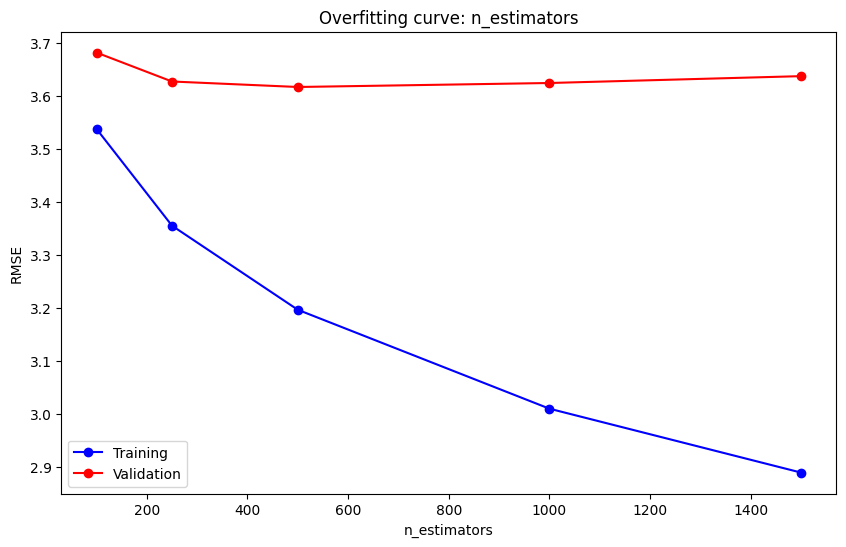

In [88]:
%%time 
test_param_and_plot(XGBRegressor, 'n_estimators', [100, 250, 500, 1000, 1500], **best_params)

Seems like 500 estimators has the lowest validation loss.

In [89]:
best_params['n_estimators'] = 1500

### Max Depth

In [ ]:
%%time 
test_param_and_plot(XGBRegressor, 'max_depth', [3, 4, 5, 6, 7, 8], **best_params)

Looks like a max depth of 6 is ideal.

In [ ]:
best_params['max_depth'] = 8

### Learning Rate

In [ ]:
%%time 
test_param_and_plot(XGBRegressor, 'learning_rate', [0.05, 0.1, 0.2, 0.4], **best_params)

NameError: name 'test_param_and_plot' is not defined

In [ ]:
best_params['learning_rate'] = 0.1

### Other Parameters

In [ ]:
xgb_model_final = XGBRegressor(objective='reg:squarederror',
                               n_jobs=-1, 
                               random_state=42,
                               n_estimators=1500, 
                               max_depth=8, 
                               learning_rate=0.1, 
                               subsample=0.8, 
                               colsample_bytree=0.8,
                               tree_method='gpu_hist',       
                               predictor='gpu_predictor',     
                               gpu_id=0)

Using 1000 estimators and max depth of 7 because we are using GPU for XGB

In [ ]:
xgb_model_final.fit(train_inputs, train_targets)

c:\Users\Prabhjot\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:07:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\Prabhjot\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:07:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "predictor" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [ ]:
evaluate(xgb_model_final)

c:\Users\Prabhjot\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\core.py:2676: UserWarning: [12:09:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  if len(data.shape) != 1 and self.num_features() != data.shape[1]:


(3.0630807876586914,
 3.5940840244293213,
 array([39.429176,  8.026224,  9.64889 , ..., 11.207692, 11.627738,
         8.98407 ], dtype=float32),
 array([ 9.075584 , 12.752445 , 11.577887 , ...,  5.8075194,  3.8395224,
         7.4800196], dtype=float32))

In [ ]:
predict_and_submit(xgb_model_final, 'xgb_tuned_submission.csv')

,key,fare_amount
0,2015-01-27 13:08:24.0000002,10.306724
1,2015-01-27 13:08:24.0000003,10.789101
2,2011-10-08 11:53:44.0000002,4.444487
3,2012-12-01 21:12:12.0000002,9.047116
4,2012-12-01 21:12:12.0000003,16.294064
...,...,...
9909,2015-05-10 12:37:51.0000002,9.285740
9910,2015-01-12 17:05:51.0000001,11.402433
9911,2015-04-19 20:44:15.0000001,53.619347
9912,2015-01-31 01:05:19.0000005,19.499298


## 9. Train on GPU with entire dataset (Optional)

Steps:
- Install `dask`, `cudf` and `cuml`
- Load the dataset to GPU
- Create training and validation set
- Perform feature engineering
- Train XGBoost `cuml` model
- Make predictions & submit

Follow these guides and fill out the empty cells below:
- https://towardsdatascience.com/nyc-taxi-fare-prediction-605159aa9c24
- https://jovian.ai/allenkong221/nyc-taxi-fare-rapids-dask-gpu/v/1?utm_source=embed#C10

### Install `dask`, `cudf`, `cuda` and `cuml`

## 10. Document & Publish Your Work

- Add explanations using Markdown
- Clean up the code & create functions
- Publish notebook to Jovian
- Write a blog post and embed

Follow this guide: https://www.youtube.com/watch?v=NK6UYg3-Bxs 

## References

* Dataset: https://www.kaggle.com/c/new-york-city-taxi-fare-prediction/overview
* Missing semester (Shell scripting): https://missing.csail.mit.edu/
* Opendatsets library: https://github.com/JovianML/opendatasets 
* EDA project from scratch: https://www.youtube.com/watch?v=kLDTbavcmd0
* GeoPy: https://geopy.readthedocs.io/en/stable/#module-geopy.distance 
* Blog post by Allen Kong: https://towardsdatascience.com/nyc-taxi-fare-prediction-605159aa9c24 
* Machine Learning with Python: Zero to GBMs - https://zerotogbms.com 
* Experiment tracking spreadsheet: https://bit.ly/mltrackingsheet 
* Pandas datetime components: https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#time-date-components 
* Haversine distance: https://en.wikipedia.org/wiki/Haversine_formula 
* Haversine distance with Numpy: https://stackoverflow.com/questions/29545704/fast-haversine-approximation-python-pandas 
* RAPIDS (parent project for cudf and cuml): https://rapids.ai/
* Data Science blog post from scratch: https://www.youtube.com/watch?v=NK6UYg3-Bxs 
* Examples of Machine Learning Projects:
    * Walmart Store Sales: https://jovian.ai/anushree-k/final-walmart-simple-rf-gbm
    * Used Car Price Prediction: https://jovian.ai/kara-mounir/used-cars-prices 
    * Lithology Prediction: https://jovian.ai/ramysaleem/ml-project-machine-predicting-lithologies
    * Ad Demand Prediction: https://jovian.ai/deepa-sarojam/online-ad-demand-prediction-ml-prj 
